# 05 — Anomaly Detection Notebook

This notebook mirrors the Unusual Countries page. It compares Isolation Forest and Local Outlier Factor, then builds a consensus anomaly flag based on them.

## Rule
Anomaly detection uses country averages, not yearly rows. We are asking: which countries look unusual overall compared with other countries?

In [8]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATHS = [
    PROJECT_ROOT / "sample_datasets" / "world_panel_2010_2023.csv",
    PROJECT_ROOT / "data" / "raw" / "world_panel_2010_2023.csv",
    Path("sample_datasets/world_panel_2010_2023.csv"),
]
DATA_PATH = next((p for p in DATA_PATHS if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Could not find world_panel_2010_2023.csv. Put this notebook folder in the project root.")

CHARTS_DIR = PROJECT_ROOT / "charts" / Path.cwd().name.replace(" ", "_")
if Path.cwd().name != "notebooks":
    CHARTS_DIR = PROJECT_ROOT / "charts" / "05_anomaly_detection"
PROCESSED_DIR = PROJECT_ROOT / "after_processing_dataset"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def save_mpl(name, dpi=160):
    path = CHARTS_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved chart: {path}")
    plt.show()

def save_df(df, name):
    path = PROCESSED_DIR / name
    df.to_csv(path, index=False)
    print(f"Saved dataset: {path}")
    return path

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

numeric_cols = df.select_dtypes(include="number").columns.tolist()
feature_cols = [c for c in numeric_cols if c != "year"]
country_profile = df.groupby(["country", "code", "region"], as_index=False)[feature_cols].mean()
X_imp = SimpleImputer(strategy="median").fit_transform(country_profile[feature_cols])
X = StandardScaler().fit_transform(X_imp)

pca2 = PCA(n_components=2, random_state=42)
coords = pca2.fit_transform(X)
plot_base = country_profile[["country", "code", "region"]].copy()
plot_base["PC1"] = coords[:,0]
plot_base["PC2"] = coords[:,1]

Loaded: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\sample_datasets\world_panel_2010_2023.csv
Shape: (336, 22)


,country,code,region,year,gdp_per_capita,hdi,life_expectancy,literacy_rate,internet_usage_pct,co2_per_capita,...,education_spending_pct,health_spending_pct,gini_index,political_stability,urbanization_rate,unemployment_rate,renewable_energy_pct,access_to_water_pct,maternal_mortality,population
0,Algeria,DZA,Africa,2010,4228.1,0.4909,72.14,87.32,25.38,1.185,...,5.521,8.038,50.25,0.1510,53.42,14.99,39.19,67.62,553.0,260960120
1,Algeria,DZA,Africa,2011,4374.9,0.4849,72.37,86.10,34.32,1.176,...,5.321,7.755,52.43,0.2402,53.22,10.16,37.60,68.63,551.4,268501465
2,Algeria,DZA,Africa,2012,4500.8,0.4914,72.45,87.41,33.08,1.145,...,5.152,7.301,44.42,-0.0675,52.50,14.07,43.97,67.39,554.0,276758265
3,Algeria,DZA,Africa,2013,4649.6,0.4930,72.46,87.03,31.79,1.453,...,5.712,7.988,50.39,0.0478,54.45,11.86,43.34,68.68,522.7,285130821
4,Algeria,DZA,Africa,2014,4744.8,0.4983,72.98,89.22,34.49,1.174,...,5.411,8.000,46.90,0.1721,53.59,11.30,43.23,67.58,524.3,292485149


## 1. Fit Anomaly Methods

In [9]:
contamination = min(0.18, max(0.05, 4 / len(country_profile)))
print("Contamination used:", contamination)

iso = IsolationForest(contamination=contamination, n_estimators=200, random_state=42)
iso_pred = iso.fit_predict(X)
iso_score = iso.decision_function(X)

lof = LocalOutlierFactor(contamination=contamination, n_neighbors=min(10, len(country_profile)-1))
lof_pred = lof.fit_predict(X)
lof_score = lof.negative_outlier_factor_

results = country_profile[["country","code","region"]].copy()
results["iso_anomaly"] = (iso_pred == -1).astype(int)
results["iso_score"] = iso_score
results["lof_anomaly"] = (lof_pred == -1).astype(int)
results["lof_score"] = lof_score

results["consensus_votes"] = results[["iso_anomaly","lof_anomaly"]].sum(axis=1)
results["consensus_anomaly"] = (results["consensus_votes"] == 2).astype(int)

display(results.sort_values("consensus_votes", ascending=False).head(15))
save_df(results, "anomaly_detection_results_methods.csv")

Contamination used: 0.16666666666666666


,country,code,region,iso_anomaly,iso_score,lof_anomaly,lof_score,consensus_votes,consensus_anomaly
16,Singapore,SGP,Asia,1,-0.043441,1,-1.362870,2,1
12,Norway,NOR,Europe,1,-0.020116,1,-1.327397,2,1
19,Spain,ESP,Europe,0,0.012387,1,-1.240781,1,0
17,Somalia,SOM,Africa,1,-0.073211,0,-1.195659,1,0
22,USA,USA,Americas,0,0.004023,1,-1.275203,1,0
23,Yemen,YEM,Asia,1,-0.030215,0,-1.140802,1,0
0,Algeria,DZA,Africa,0,0.141054,0,-0.977480,0,0
1,Australia,AUS,Oceania,0,0.056554,0,-1.227999,0,0
7,India,IND,Asia,0,0.061404,0,-1.014431,0,0
6,Germany,DEU,Europe,0,0.044379,0,-1.214610,0,0


Saved dataset: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\after_processing_dataset\anomaly_detection_results_methods.csv


WindowsPath('c:/Users/moham/Desktop/World_Development_FINAL_PAGED-2/after_processing_dataset/anomaly_detection_results_methods.csv')

## 2. PCA anomaly map

Saved chart: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\charts\notebooks\isolation_forest_pca_anomalies.png


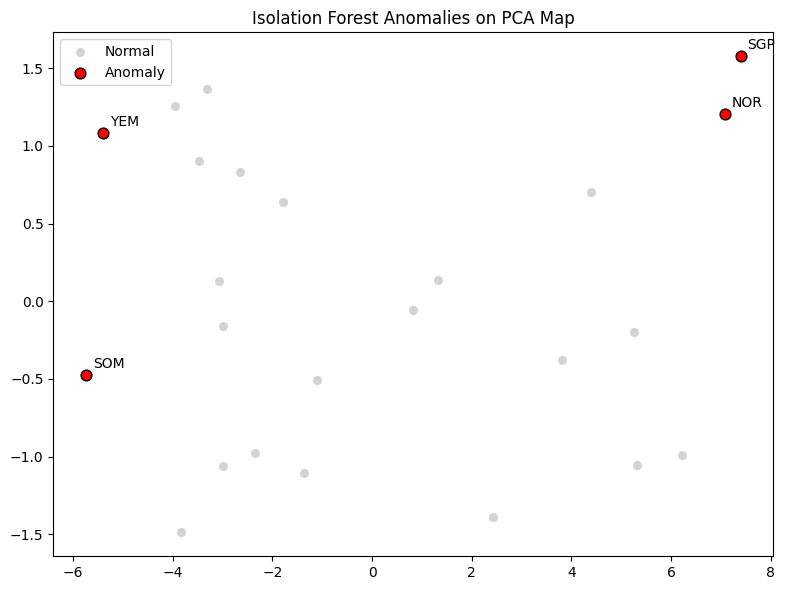

Saved chart: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\charts\notebooks\lof_pca_anomalies.png


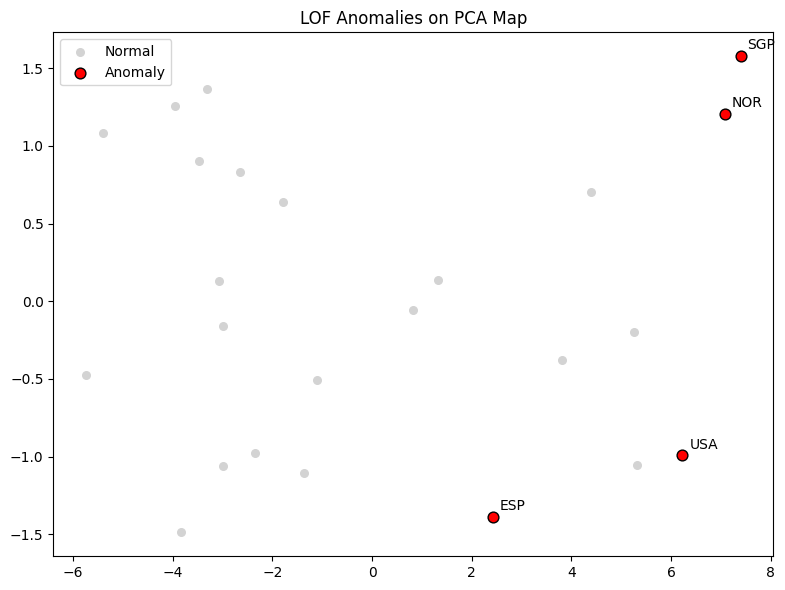

Saved chart: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\charts\notebooks\consensus_pca_anomalies.png


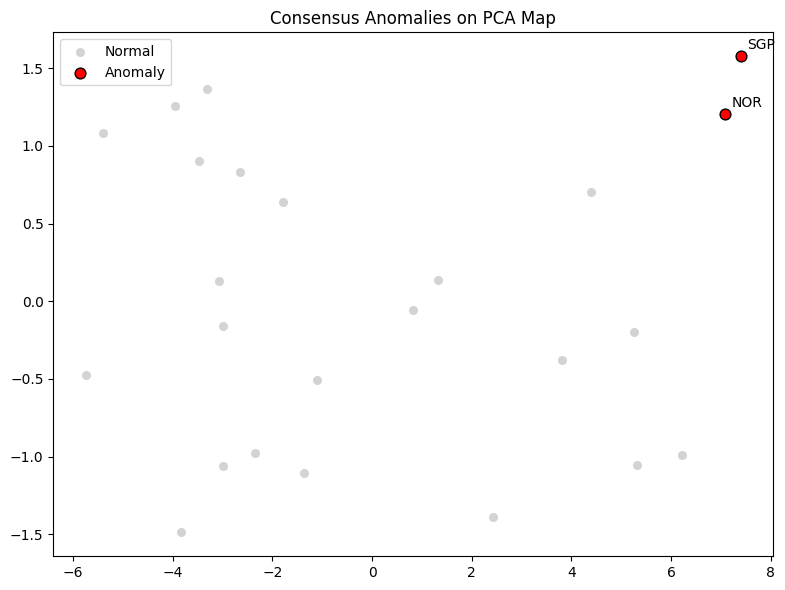

In [10]:
def anomaly_map(col, title, filename):
    fig, ax = plt.subplots(figsize=(8,6))
    normal = plot_base[results[col] == 0]
    anom = plot_base[results[col] == 1]
    
    ax.scatter(normal["PC1"], normal["PC2"], c="lightgray", s=30, label="Normal")
    ax.scatter(anom["PC1"], anom["PC2"], c="red", s=60, label="Anomaly", edgecolor="black")
    
    for _, r in anom.iterrows():
        ax.annotate(r["code"], (r["PC1"], r["PC2"]), xytext=(5,5), textcoords="offset points")
        
    ax.set_title(title)
    ax.legend()
    save_mpl(filename)

anomaly_map("iso_anomaly", "Isolation Forest Anomalies on PCA Map", "isolation_forest_pca_anomalies.png")
anomaly_map("lof_anomaly", "LOF Anomalies on PCA Map", "lof_pca_anomalies.png")
anomaly_map("consensus_anomaly", "Consensus Anomalies on PCA Map", "consensus_pca_anomalies.png")

## 3. Method agreement chart

,method,anomaly_count
0,iso_anomaly,4
1,lof_anomaly,4
2,consensus_anomaly,2


Saved dataset: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\after_processing_dataset\anomaly_method_counts.csv
Saved chart: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\charts\notebooks\anomaly_method_counts.png


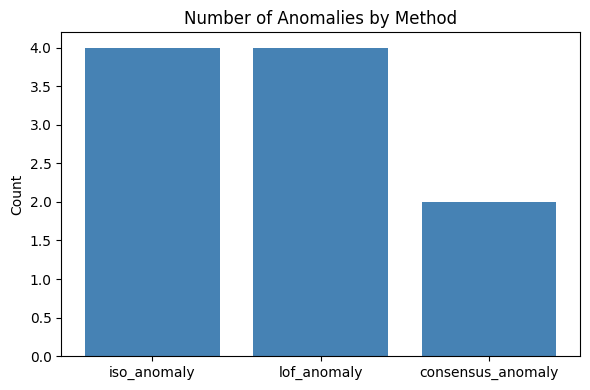

In [11]:
counts = pd.DataFrame({
    "method": ["iso_anomaly", "lof_anomaly", "consensus_anomaly"],
    "anomaly_count": [
        results["iso_anomaly"].sum(),
        results["lof_anomaly"].sum(),
        results["consensus_anomaly"].sum()
    ]
})
display(counts)
save_df(counts, "anomaly_method_counts.csv")

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(counts["method"], counts["anomaly_count"], color="steelblue")
ax.set_title("Number of Anomalies by Method")
ax.set_ylabel("Count")
save_mpl("anomaly_method_counts.png")

## 4. Compare averages

In [12]:
comparison = country_profile.copy()
comparison["group"] = np.where(results["consensus_anomaly"] == 1, "Consensus Anomaly", "Normal")
comparison_means = comparison.groupby("group")[feature_cols].mean().T
display(comparison_means)
save_df(comparison_means.reset_index(), "anomaly_profile_comparison.csv")

group,Consensus Anomaly,Normal
gdp_per_capita,1.246870e+05,2.206592e+04
hdi,9.804000e-01,6.188133e-01
life_expectancy,8.541536e+01,7.596071e+01
literacy_rate,9.976179e+01,9.246149e+01
internet_usage_pct,6.826464e+01,5.104214e+01
co2_per_capita,2.384436e+01,5.995968e+00
fertility_rate,1.346000e+00,3.490552e+00
infant_mortality,5.089286e+00,4.630536e+01
education_spending_pct,8.390321e+00,6.167584e+00
health_spending_pct,1.360100e+01,9.244162e+00


Saved dataset: c:\Users\moham\Desktop\World_Development_FINAL_PAGED-2\after_processing_dataset\anomaly_profile_comparison.csv


WindowsPath('c:/Users/moham/Desktop/World_Development_FINAL_PAGED-2/after_processing_dataset/anomaly_profile_comparison.csv')

## 5. Show Top Outliers

In [13]:
display(results.sort_values("iso_score").head(10))
display(results.sort_values("lof_score").head(10))
print("Interpretation: lower Isolation Forest / LOF scores usually mean stronger anomaly behavior.")

,country,code,region,iso_anomaly,iso_score,lof_anomaly,lof_score,consensus_votes,consensus_anomaly
17,Somalia,SOM,Africa,1,-0.073211,0,-1.195659,1,0
16,Singapore,SGP,Asia,1,-0.043441,1,-1.362870,2,1
23,Yemen,YEM,Asia,1,-0.030215,0,-1.140802,1,0
12,Norway,NOR,Europe,1,-0.020116,1,-1.327397,2,1
22,USA,USA,Americas,0,0.004023,1,-1.275203,1,0
19,Spain,ESP,Europe,0,0.012387,1,-1.240781,1,0
3,China,CHN,Asia,0,0.027495,0,-1.184324,0,0
5,France,FRA,Europe,0,0.033368,0,-1.214610,0,0
15,Saudi Arabia,SAU,Asia,0,0.034997,0,-1.215179,0,0
6,Germany,DEU,Europe,0,0.044379,0,-1.214610,0,0


,country,code,region,iso_anomaly,iso_score,lof_anomaly,lof_score,consensus_votes,consensus_anomaly
16,Singapore,SGP,Asia,1,-0.043441,1,-1.362870,2,1
12,Norway,NOR,Europe,1,-0.020116,1,-1.327397,2,1
22,USA,USA,Americas,0,0.004023,1,-1.275203,1,0
19,Spain,ESP,Europe,0,0.012387,1,-1.240781,1,0
14,Qatar,QAT,Asia,0,0.050363,0,-1.236355,0,0
1,Australia,AUS,Oceania,0,0.056554,0,-1.227999,0,0
15,Saudi Arabia,SAU,Asia,0,0.034997,0,-1.215179,0,0
6,Germany,DEU,Europe,0,0.044379,0,-1.214610,0,0
5,France,FRA,Europe,0,0.033368,0,-1.214610,0,0
17,Somalia,SOM,Africa,1,-0.073211,0,-1.195659,1,0


Interpretation: lower Isolation Forest / LOF scores usually mean stronger anomaly behavior.
